# Support Vector Machines — Multi-class Classification of `sii`

**Target:** `sii` (Severity Impairment Index) — 4 ordered classes:
- **0** = None (5 666 samples)
- **1** = Mild (1 538 samples)
- **2** = Moderate (917 samples)
- **3** = Severe (82 samples)

Support Vector Machines find the decision boundary that maximises the margin between classes. Through the **kernel trick** they implicitly map features into a high-dimensional space, so — unlike Logistic Regression — they can carve out **non-linear** decision boundaries (RBF, polynomial) while remaining a max-margin method. Three design choices are critical here:
1. **Feature scaling** (`StandardScaler`): SVMs are distance/inner-product based, so unscaled features with large ranges would dominate the kernel.
2. **Class imbalance handling** via balanced weights, so minority classes (Moderate, Severe) push the margin proportionally to their inverse frequency.
3. **Kernel & regularisation choice** (`C`, `gamma`, `kernel`): these jointly control the bias–variance trade-off and are the focus of the tuning phase.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from scipy.stats import loguniform

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

## 1. Data Loading

In [3]:
df = pd.read_csv("../../outlier_data/cmi_consensus_clean.csv", index_col="id")
print(f"Shape: {df.shape}")
df.head()

Shape: (8193, 20)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PCIAT-PCIAT_Total,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,,
0,5,0,51.0,116.8400,23.042474,89.8,2,16.8792,1492.00,41.5862,13.8177,3.06143,1,55,3,2,84.200000,2.123081,3,2.2580
1,9,0,57.7,121.9200,20.865232,70.0,2,14.0371,1498.65,42.0291,12.8254,1.21172,1,0,0,0,90.666667,0.828527,4,2.1750
2,10,1,71.0,143.5100,34.291555,94.0,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,28,2,0,82.333333,5.546522,5,2.0900
3,9,0,71.0,142.2400,37.013107,97.0,3,18.2943,1923.44,62.7757,14.0740,4.22033,2,44,0,1,79.000000,6.967458,4,2.2305
4,18,1,65.0,138.8618,34.926584,73.8,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,29,1,0,83.333333,5.649235,5,1.5650


In [4]:
# PCIAT_Total is excluded — it is the source of `sii` (would be perfect leakage) and is reserved for regression.
feature_columns = [col for col in df.columns if col not in ("sii", "PCIAT-PCIAT_Total")]

X = df[feature_columns]
y = df["sii"].astype(int)

class_names = ["None (0)", "Mild (1)", "Moderate (2)", "Severe (3)"]
num_classes = len(class_names)

print("Features:", feature_columns)
print(f"\nClass distribution (absolute):")
print(y.value_counts().sort_index())
print(f"\nClass distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(1))

Features: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-HeartRate', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Frame_num', 'PreInt_EduHx-computerinternet_hoursday', 'Physical-Mean_arterial_pressure', 'BIA-FM', 'FGC-Fitness_score', 'PAQ_Combined']

Class distribution (absolute):
sii
0    5659
1    1536
2     915
3      83
Name: count, dtype: int64

Class distribution (%):
sii
0    69.1
1    18.7
2    11.2
3     1.0
Name: proportion, dtype: float64


## 2. Train / Test Split & Feature Scaling

SVMs are **scale-sensitive**: the RBF and polynomial kernels depend on inner products / Euclidean distances between samples, so a feature with a large numeric range would dominate the kernel and effectively mask the others. `StandardScaler` is fit only on the training set to avoid leakage.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train samples: {X_train_scaled.shape[0]}")
print(f"Test  samples: {X_test_scaled.shape[0]}")
print(f"\nTrain class distribution:")
print(y_train.value_counts().sort_index())

Train samples: 6554
Test  samples: 1639

Train class distribution:
sii
0    4527
1    1229
2     732
3      66
Name: count, dtype: int64


### Class imbalance — Sample Weights

`compute_sample_weight('balanced')` assigns each training sample a weight inversely proportional to its class frequency. Passing these weights through `fit(sample_weight=...)` is mathematically equivalent to `class_weight='balanced'`, but is also propagated correctly through `RandomizedSearchCV` so the **CV folds themselves** see weighted training (and unweighted scoring on `f1_macro`, which is already class-symmetric).

In [6]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

for cls in sorted(y_train.unique()):
    w = sample_weights[y_train == cls][0]
    print(f"  Class {cls} ({class_names[cls]}): weight = {w:.4f}")

  Class 0 (None (0)): weight = 0.3619
  Class 1 (Mild (1)): weight = 1.3332
  Class 2 (Moderate (2)): weight = 2.2384
  Class 3 (Severe (3)): weight = 24.8258


## 3. Baseline SVM

The baseline uses the default **RBF kernel** with `C=1.0`, `gamma='scale'` and balanced class weights. The RBF kernel is the standard general-purpose choice and establishes a fair reference point before tuning.

In [7]:
svm_base = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=RANDOM_STATE
)
svm_base.fit(X_train_scaled, y_train)

y_pred_base = svm_base.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_base))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Accuracy: 0.446

Confusion Matrix:
 [[555 252 194 131]
 [102 112  71  22]
 [ 45  54  62  22]
 [  5   4   6   2]]

Classification Report:
               precision    recall  f1-score   support

    None (0)       0.79      0.49      0.60      1132
    Mild (1)       0.27      0.36      0.31       307
Moderate (2)       0.19      0.34      0.24       183
  Severe (3)       0.01      0.12      0.02        17

    accuracy                           0.45      1639
   macro avg       0.31      0.33      0.29      1639
weighted avg       0.61      0.45      0.50      1639



## 4. Hyperparameter Tuning — RandomizedSearchCV

Not every (kernel, parameter) combination is meaningful — `gamma` and `degree` only apply to some kernels — so the search uses **compatibility-aware sub-grids** instead of a single grid (which would waste iterations exploring inert parameters).

**Parameters tested:**

| Parameter | Values | Rationale |
|---|---|---|
| `C` | log-uniform in [1e-2, 1e3] | Penalty on margin violations — low `C` = wider, softer margin (more regularisation); high `C` = harder margin |
| `kernel` | `rbf`, `poly`, `linear` | From linear boundary to flexible non-linear ones |
| `gamma` | `scale`, `auto`, log-uniform [1e-4, 1e1] | Reach of a single training sample — high `gamma` = wiggly, local boundaries (risk of overfit) |
| `degree` | 2, 3, 4 | Polynomial degree (only used by `poly`) |
| `coef0` | 0.0, 1.0 | Independent term in `poly` |
| `class_weight` | `balanced`, `None` | Confirms balancing helps despite `sample_weight` being passed explicitly |

We run **40 random combinations** with **5-fold stratified CV**, scoring on **macro F1**. SVM training is super-linear in the number of samples, so the iteration budget is smaller than for Logistic Regression.

In [8]:
# Compatibility-aware sub-grids: every drawn combination exercises only its relevant parameters.
param_dist = [
    {
        "kernel":       ["rbf"],
        "C":            loguniform(1e-2, 1e3),
        "gamma":        ["scale", "auto"],
        "class_weight": ["balanced", None],
    },
    {
        "kernel":       ["poly"],
        "C":            loguniform(1e-2, 1e3),
        "gamma":        ["scale", "auto"],
        "degree":       [2, 3, 4],
        "coef0":        [0.0, 1.0],
        "class_weight": ["balanced", None],
    },
    {
        "kernel":       ["linear"],
        "C":            loguniform(1e-2, 1e3),
        "class_weight": ["balanced", None],
    },
]

base_svm = SVC(random_state=RANDOM_STATE)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_search = RandomizedSearchCV(
    estimator=base_svm,
    param_distributions=param_dist,
    n_iter=40,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

svm_search.fit(X_train_scaled, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'C': <scipy.stats....x7f8ca7b3d550>, 'class_weight': ['balanced', None], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}, {'C': <scipy.stats....x7f8ca7c7ac10>, 'class_weight': ['balanced', None], 'coef0': [0.0, 1.0], 'degree': [2, 3, ...], ...}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be t

In [9]:
print("Best Parameters:", svm_search.best_params_)
print("Best CV F1 Score (macro):", round(svm_search.best_score_, 4))

Best Parameters: {'C': np.float64(0.10199902295182439), 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1 Score (macro): 0.3629


The tuning trades off margin width (`C`) against boundary flexibility (`kernel`, `gamma`, `degree`). On tabular data of this size the RBF kernel with a moderate `C` and `gamma='scale'` is a common optimum: large enough to bend around minority-class regions, small enough to avoid memorising noise. A linear kernel winning would suggest the classes are close to linearly separable in the scaled feature space (and would echo the Logistic Regression result).

## 5. Tuned Model Evaluation

In [10]:
best_svm = svm_search.best_estimator_

y_pred_train = best_svm.predict(X_train_scaled)
y_pred_test = best_svm.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test  accuracy: {test_acc:.3f}\n")

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=class_names, zero_division=0))

Train accuracy: 0.441
Test  accuracy: 0.413

Confusion Matrix (Test Set):
[[532 171 227 202]
 [ 99  73  87  48]
 [ 40  29  68  46]
 [  4   1   8   4]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    None (0)       0.79      0.47      0.59      1132
    Mild (1)       0.27      0.24      0.25       307
Moderate (2)       0.17      0.37      0.24       183
  Severe (3)       0.01      0.24      0.03        17

    accuracy                           0.41      1639
   macro avg       0.31      0.33      0.28      1639
weighted avg       0.61      0.41      0.48      1639



A large gap between train and test accuracy would flag an over-flexible kernel (too high `gamma`/`C`); keeping them close indicates the chosen margin generalises. As with the other linear-ish baselines, the bottleneck is the minority **Severe** class, where only a handful of support vectors are available.

## 6. Permutation Feature Importance

Unlike Logistic Regression, a non-linear SVM (RBF/poly) does **not** expose interpretable per-feature coefficients — `coef_` is only defined for the `linear` kernel. We therefore use **permutation importance**, a model-agnostic method: each feature is randomly shuffled in turn and the drop in macro-F1 is measured. A large drop means the model relied heavily on that feature. This is the same lens used for the MLP, making the rankings directly comparable.

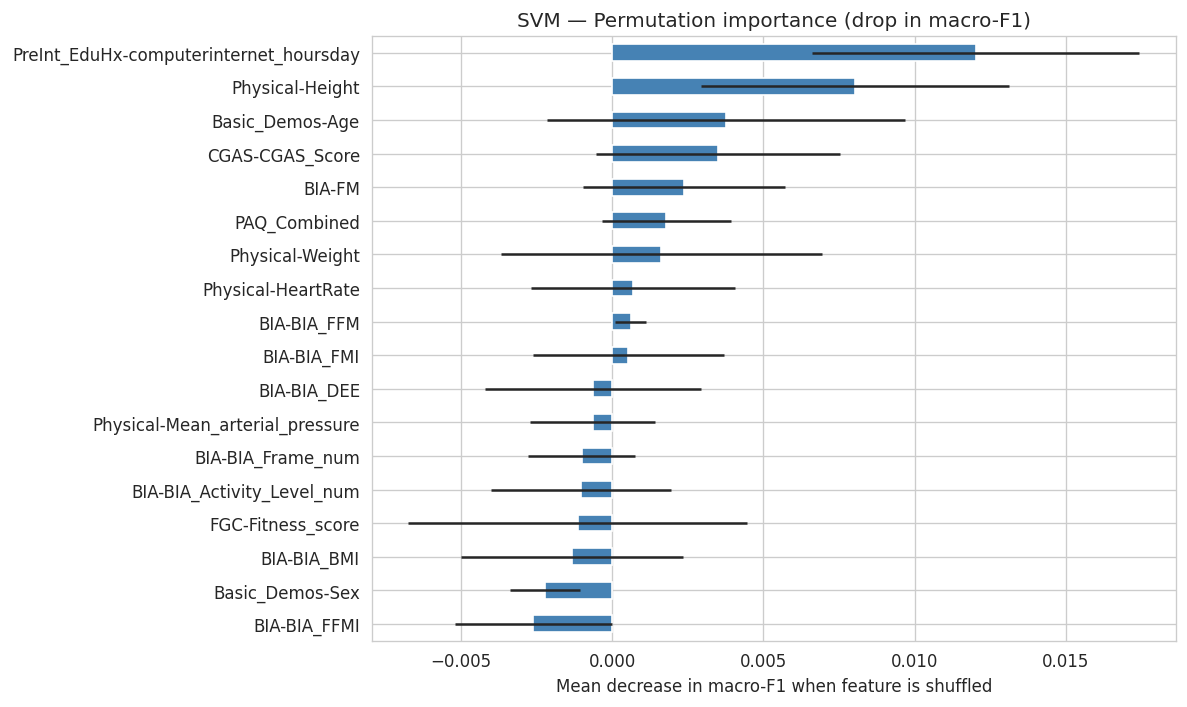

In [11]:
perm = permutation_importance(
    best_svm, X_test_scaled, y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importances = pd.Series(perm.importances_mean, index=feature_columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue",
                 xerr=perm.importances_std[np.argsort(perm.importances_mean)])
plt.title("SVM — Permutation importance (drop in macro-F1)")
plt.xlabel("Mean decrease in macro-F1 when feature is shuffled")
plt.tight_layout()
plt.show()

Features whose permutation most degrades macro-F1 are the ones the SVM leans on most. We expect `PreInt_EduHx-computerinternet_hoursday` and `CGAS-CGAS_Score` to dominate, in line with the coefficient ranking from Logistic Regression and the permutation ranking from the MLP — a reassuring sign of agreement across model families.

## 7. Confusion Matrix

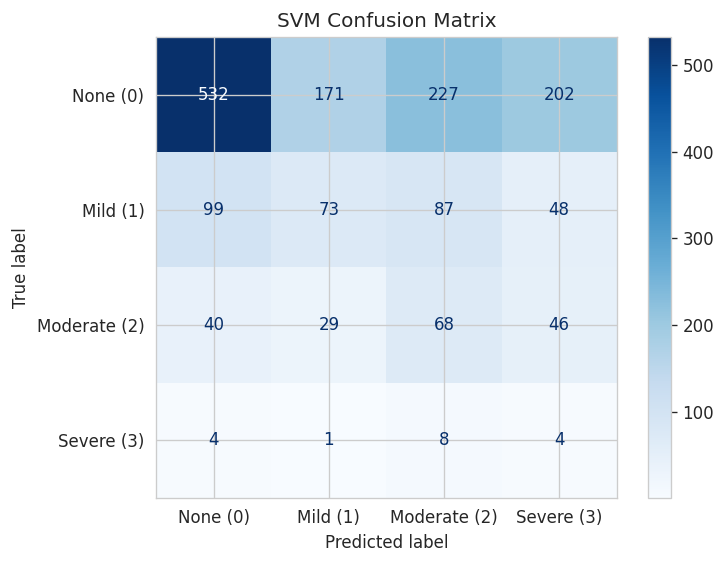

In [12]:
cm = confusion_matrix(y_test, y_pred_test, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

Most errors are between adjacent classes, consistent with the ordinal nature of `sii`. Confusion between the extremes (None vs Severe) is rare, suggesting the max-margin boundary respects the underlying severity ordering.

## 8. ROC Curves (One-vs-Rest)

`SVC` does not return calibrated probabilities by default, so we use the **`decision_function`** scores (signed distance to each one-vs-rest hyperplane) to build the ROC curves. Ranking quality — not absolute probability calibration — is what the ROC/AUC measures, and the decision scores are a faithful ranking.

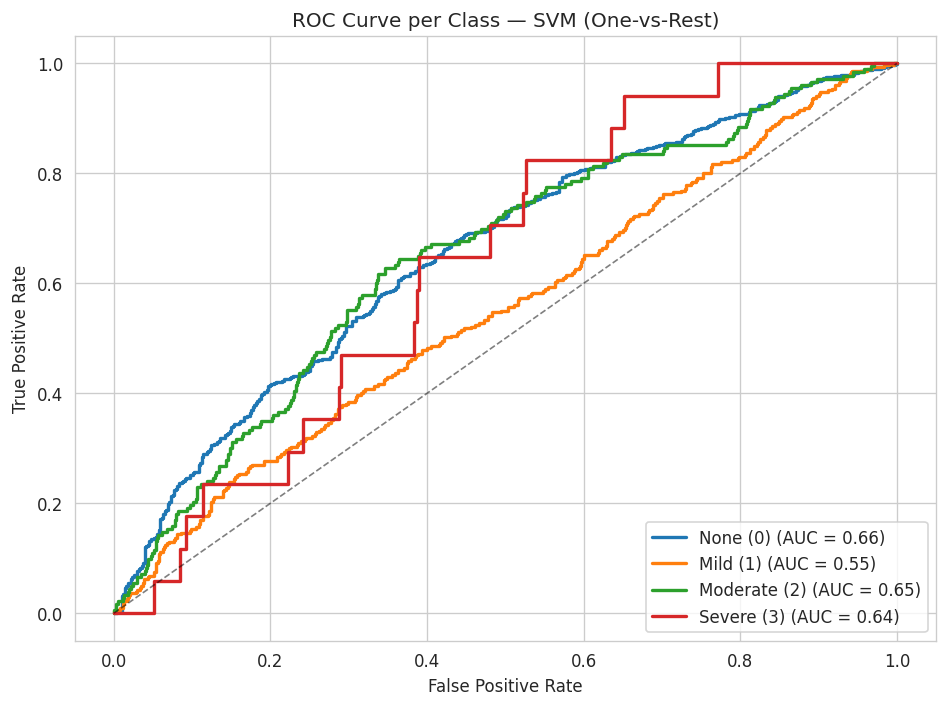

In [13]:
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
y_score = best_svm.decision_function(X_test_scaled)

plt.figure(figsize=(8, 6))
colors_roc = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, (class_label, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class — SVM (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The two extremes of the ordinal scale — None and Severe — are typically the easiest to separate, while Mild and Moderate sit in a region of overlapping decision scores. The AUC values show that the max-margin decision function produces a meaningful ranking suitable for thresholded decision-making (e.g., flagging the most likely Severe cases for follow-up), comparable to the other classifiers in this module.